In [27]:
import os
import urllib.request
import zipfile
import tarfile
import numpy as np
import cv2 as cv
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import drive

print("Tensorflow verzija: " + tf.__version__)
print("Keras verzija: " + tf.keras.__version__)

Tensorflow verzija: 2.19.0
Keras verzija: 3.13.2


In [28]:
########################################################################################################################
# 1. MONTIRANJE GOOGLE DRIVE-A I PODEŠAVANJE PUTANJA
########################################################################################################################

drive.mount('/content/drive')

# Putanja na Google Drive-u gde će se čuvati rezultati
drive_results_folder = '/content/drive/MyDrive/Caltech101_Results_Keras'
if not os.path.exists(drive_results_folder):
    os.makedirs(drive_results_folder)
    print(f"Napravljen direktorijum za rezultate na Drive-u: {drive_results_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
########################################################################################################################
# 2. PREUZIMANJE I RASPAKIVANJE PODATAKA
########################################################################################################################

dataset_url = "https://data.caltech.edu/records/mzrjq-6wc02/files/caltech-101.zip"
zip_path = "/content/caltech-101.zip"
caltech_folder = "/content/caltech-101"
data_folder = "/content/101_ObjectCategories"

if not os.path.exists(zip_path):
    print("Preuzimanje dataseta...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    print("Preuzimanje završeno.")

if not os.path.exists(caltech_folder):
    print("Raspakivanje osnovne ZIP arhive...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists(data_folder):
    print("Raspakivanje slika iz TAR.GZ arhive...")
    tar_path = os.path.join(caltech_folder, '101_ObjectCategories.tar.gz')
    with tarfile.open(tar_path, 'r:gz') as tar_ref:
        tar_ref.extractall('/content/')
    print("Slike su spremne.")

In [30]:
########################################################################################################################
# 3. FUNKCIJE ZA UČITAVANJE PODATAKA I KREIRANJE MODELA
########################################################################################################################

def load_data(image_size, keep_aspect=True, fill_value=0):
    categories = []
    train_data = []
    test_data = []

    image_folders = sorted(os.listdir(data_folder))
    for c in image_folders:
        # Izbacivanje kategorije BACKGROUND_Google
        if c == 'BACKGROUND_Google':
            continue

        path = os.path.join(data_folder, c)
        if os.path.isdir(path):
            categories.append(c)

            cnt = 0
            files = sorted(os.listdir(path))
            for f in files:
                image_file = os.path.join(path, f)
                if os.path.isfile(image_file):
                    if cnt % 5 == 2:
                        test_data.append((image_file, categories.index(c)))
                    else:
                        train_data.append((image_file, categories.index(c)))
                    cnt += 1

    x_train = np.zeros((len(train_data), image_size, image_size, 3), np.uint8)
    y_train = np.zeros((len(train_data), 1), np.uint8)
    x_test = np.zeros((len(test_data), image_size, image_size, 3), np.uint8)
    y_test = np.zeros((len(test_data), 1), np.uint8)

    for i in range(len(train_data)):
        file, c = train_data[i]
        y_train[i] = c
        img = cv.imread(file)
        if img is None:
            print("Greška pri učitavanju:", file, c)
            continue
        if keep_aspect:
            cy = img.shape[0]
            cx = img.shape[1]
            if cx > cy:
                d = cx - cy
                img = cv.copyMakeBorder(img, top=d//2, bottom=d-d//2, left=0, right=0,
                                        borderType=cv.BORDER_CONSTANT, value=fill_value)
            else:
                d = cy - cx
                img = cv.copyMakeBorder(img, top=0, bottom=0, left=d//2, right=d-d//2,
                                        borderType=cv.BORDER_CONSTANT, value=fill_value)
        img = cv.resize(img, (image_size, image_size), interpolation=cv.INTER_LINEAR)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        x_train[i] = img

    for i in range(len(test_data)):
        file, c = test_data[i]
        y_test[i] = c
        img = cv.imread(file)
        if img is None:
            continue
        if keep_aspect:
            cy = img.shape[0]
            cx = img.shape[1]
            if cx > cy:
                d = cx - cy
                img = cv.copyMakeBorder(img, top=d // 2, bottom=d - d // 2, left=0, right=0,
                                        borderType=cv.BORDER_CONSTANT, value=fill_value)
            else:
                d = cy - cx
                img = cv.copyMakeBorder(img, top=0, bottom=0, left=d // 2, right=d - d // 2,
                                        borderType=cv.BORDER_CONSTANT, value=fill_value)
        img = cv.resize(img, (image_size, image_size), interpolation=cv.INTER_LINEAR)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        x_test[i] = img

    rand_train_idx = np.random.RandomState(seed=0).permutation(len(train_data))
    x_train = x_train[rand_train_idx]
    y_train = y_train[rand_train_idx]

    rand_test_idx = np.random.RandomState(seed=0).permutation(len(test_data))
    x_test = x_test[rand_test_idx]
    y_test = y_test[rand_test_idx]

    return categories, train_data, test_data, x_train, y_train, x_test, y_test

In [31]:
########################################################################################################################
# 4. FUNKCIJA ZA KREIRANJE MODELA
########################################################################################################################

def create_model(x_train, x_test, classes, trainable_encoder=False):
    input_shape = x_train.shape[1:]

    x = tf.keras.layers.Input(shape=input_shape, name='input')

    backbone = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet',
                                                    input_tensor=x, pooling='avg', classes=classes)

    if not trainable_encoder:
        for layer in backbone.layers:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

    y = backbone.output
    y = tf.keras.layers.Dropout(rate=0.5)(y)
    y = tf.keras.layers.Dense(classes, activation='softmax', name='output')(y)

    model = tf.keras.models.Model(inputs=x, outputs=y)

    x_train_pp = tf.keras.applications.efficientnet.preprocess_input(x_train)
    x_test_pp = tf.keras.applications.efficientnet.preprocess_input(x_test)

    return x_train_pp, x_test_pp, model

Učitavanje i pretprocesiranje slika...
Oblik trening skupa: (6941, 224, 224, 3) (6941, 1)
Oblik test skupa: (1736, 224, 224, 3) (1736, 1)
Broj kategorija: 101

Prikaz prvih 10 slika iz trening skupa...


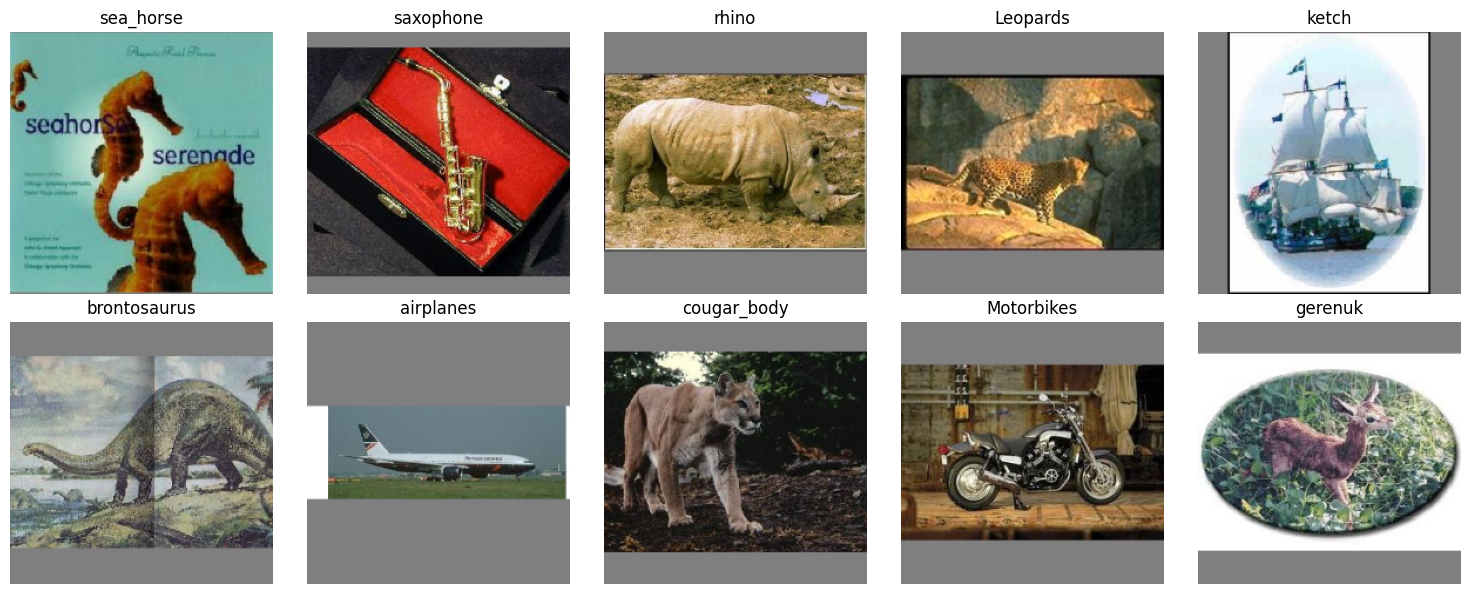

In [32]:
########################################################################################################################
# 5. UČITAVANJE I PRETPROCESIRANJE PODATAKA
########################################################################################################################

image_size = 224
batch_size = 32

print("Učitavanje i pretprocesiranje slika...")
categories, train_data, test_data, x_train, y_train, x_test, y_test = load_data(image_size, keep_aspect=True, fill_value=(127, 127, 127))
print("Oblik trening skupa:", x_train.shape, y_train.shape)
print("Oblik test skupa:", x_test.shape, y_test.shape)
print("Broj kategorija:", len(categories))

print("\nPrikaz prvih 10 slika iz trening skupa...")
plt.figure(figsize=(15, 6))  # Širina i visina prozora za prikaz

for i in range(10):
    plt.subplot(2, 5, i + 1)  # Kreiranje grida: 2 reda, 5 kolona, i-ta pozicija
    plt.imshow(x_train[i])

    # y_train je matrica dimenzija (N, 1), pa uzimamo nulti element da dobijemo indeks klase
    class_index = int(y_train[i][0])
    plt.title(categories[class_index])

    plt.axis('off')  # Isključivanje x i y osa radi preglednijeg prikaza slika

plt.tight_layout()  # Automatsko podešavanje razmaka između slika
plt.show()          # Prikaz grida u Colab ćeliji

In [33]:
########################################################################################################################
# 6. KREIRANJE MODELA I CALLBACK-OVA
########################################################################################################################

x_train_pp, x_test_pp, model = create_model(x_train, x_test, classes=len(categories), trainable_encoder=False)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_sparse_categorical_accuracy', mode='max',
                                                  patience=30, restore_best_weights=True, verbose=1)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_sparse_categorical_accuracy', mode='max',
                                                 factor=0.1, patience=10, verbose=1)

# Logovanje CSV-a na Google Drive
csv_logger = tf.keras.callbacks.CSVLogger(os.path.join(drive_results_folder, 'training.csv'))

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ input[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 171,397 (669.52 KB)

 Non-trainable params: 4,007,555 (15.29 MB)

In [34]:
########################################################################################################################
# 7. OBUČAVANJE MODELA
########################################################################################################################

print("Početak treniranja...")
hist = model.fit(x_train_pp, y_train, batch_size=batch_size, epochs=1000,
                 validation_data=(x_test_pp, y_test), verbose=1,
                 callbacks=[early_stopping, reduce_lr, csv_logger])

# Čuvanje modela na Google Drive
model_path = os.path.join(drive_results_folder, 'trained_model.keras')
model.save(model_path, include_optimizer=False)
print(f"Model sačuvan na: {model_path}")

Početak treniranja...
Epoch 1/1000
217/217 ━━━━━━━━━━━━━━━━━━━━ 111s 282ms/step - loss: 2.1053 - sparse_categorical_accuracy: 0.6011 - val_loss: 0.4941 - val_sparse_categorical_accuracy: 0.9026 - learning_rate: 0.0010
Epoch 2/1000
217/217 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - loss: 0.4321 - sparse_categorical_accuracy: 0.9113 - val_loss: 0.2386 - val_sparse_categorical_accuracy: 0.9418 - learning_rate: 0.0010
Epoch 3/1000
217/217 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - loss: 0.2283 - sparse_categorical_accuracy: 0.9471 - val_loss: 0.1846 - val_sparse_categorical_accuracy: 0.9533 - learning_rate: 0.0010
Epoch 4/1000
217/217 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - loss: 0.1576 - sparse_categorical_accuracy: 0.9628 - val_loss: 0.1655 - val_sparse_categorical_accuracy: 0.9551 - learning_rate: 0.0010
Epoch 5/1000
217/217 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - loss: 0.1210 - sparse_categorical_accuracy: 0.9708 - val_loss: 0.1536 - val_sparse_categorical_accuracy: 0.9562 - learning_rate: 0.0010
Epoch 

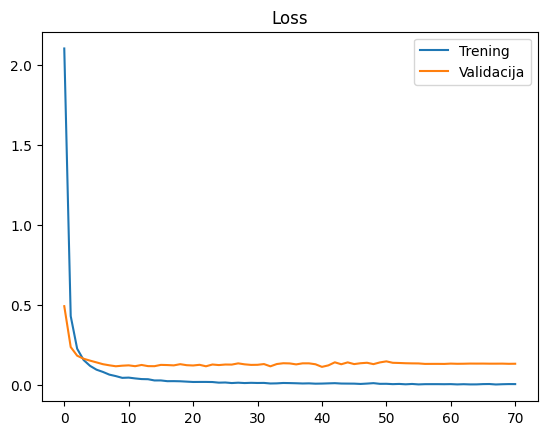

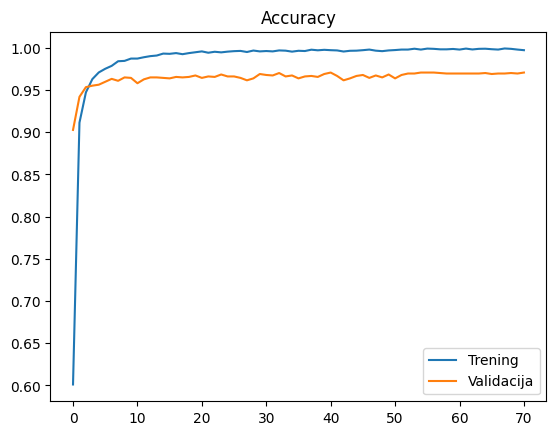

In [35]:
########################################################################################################################
# 8. PRIKAZ I ČUVANJE GRAFIKA
########################################################################################################################

plt.clf()
plt.plot(hist.history['loss'], label='Trening')
plt.plot(hist.history['val_loss'], label='Validacija')
plt.legend()
plt.title('Loss')
plt.savefig(os.path.join(drive_results_folder, 'training_loss.png'))
plt.show()

plt.clf()
plt.plot(hist.history['sparse_categorical_accuracy'], label='Trening')
plt.plot(hist.history['val_sparse_categorical_accuracy'], label='Validacija')
plt.legend()
plt.title('Accuracy')
plt.savefig(os.path.join(drive_results_folder, 'training_accuracy.png'))
plt.show()


Evaluacija modela...
Trening rezultati (Loss, Accuracy): [0.0014086130540817976, 0.9994237422943115]
Test rezultati (Loss, Accuracy): [0.11464031040668488, 0.9706221222877502]
55/55 ━━━━━━━━━━━━━━━━━━━━ 16s 172ms/step

Pogrešne predikcije (51 komada) su sačuvane na Drive-u u folderu: /content/drive/MyDrive/Caltech101_Results/misclassified

Prikaz prvih (do 25) loše klasifikovanih slika:


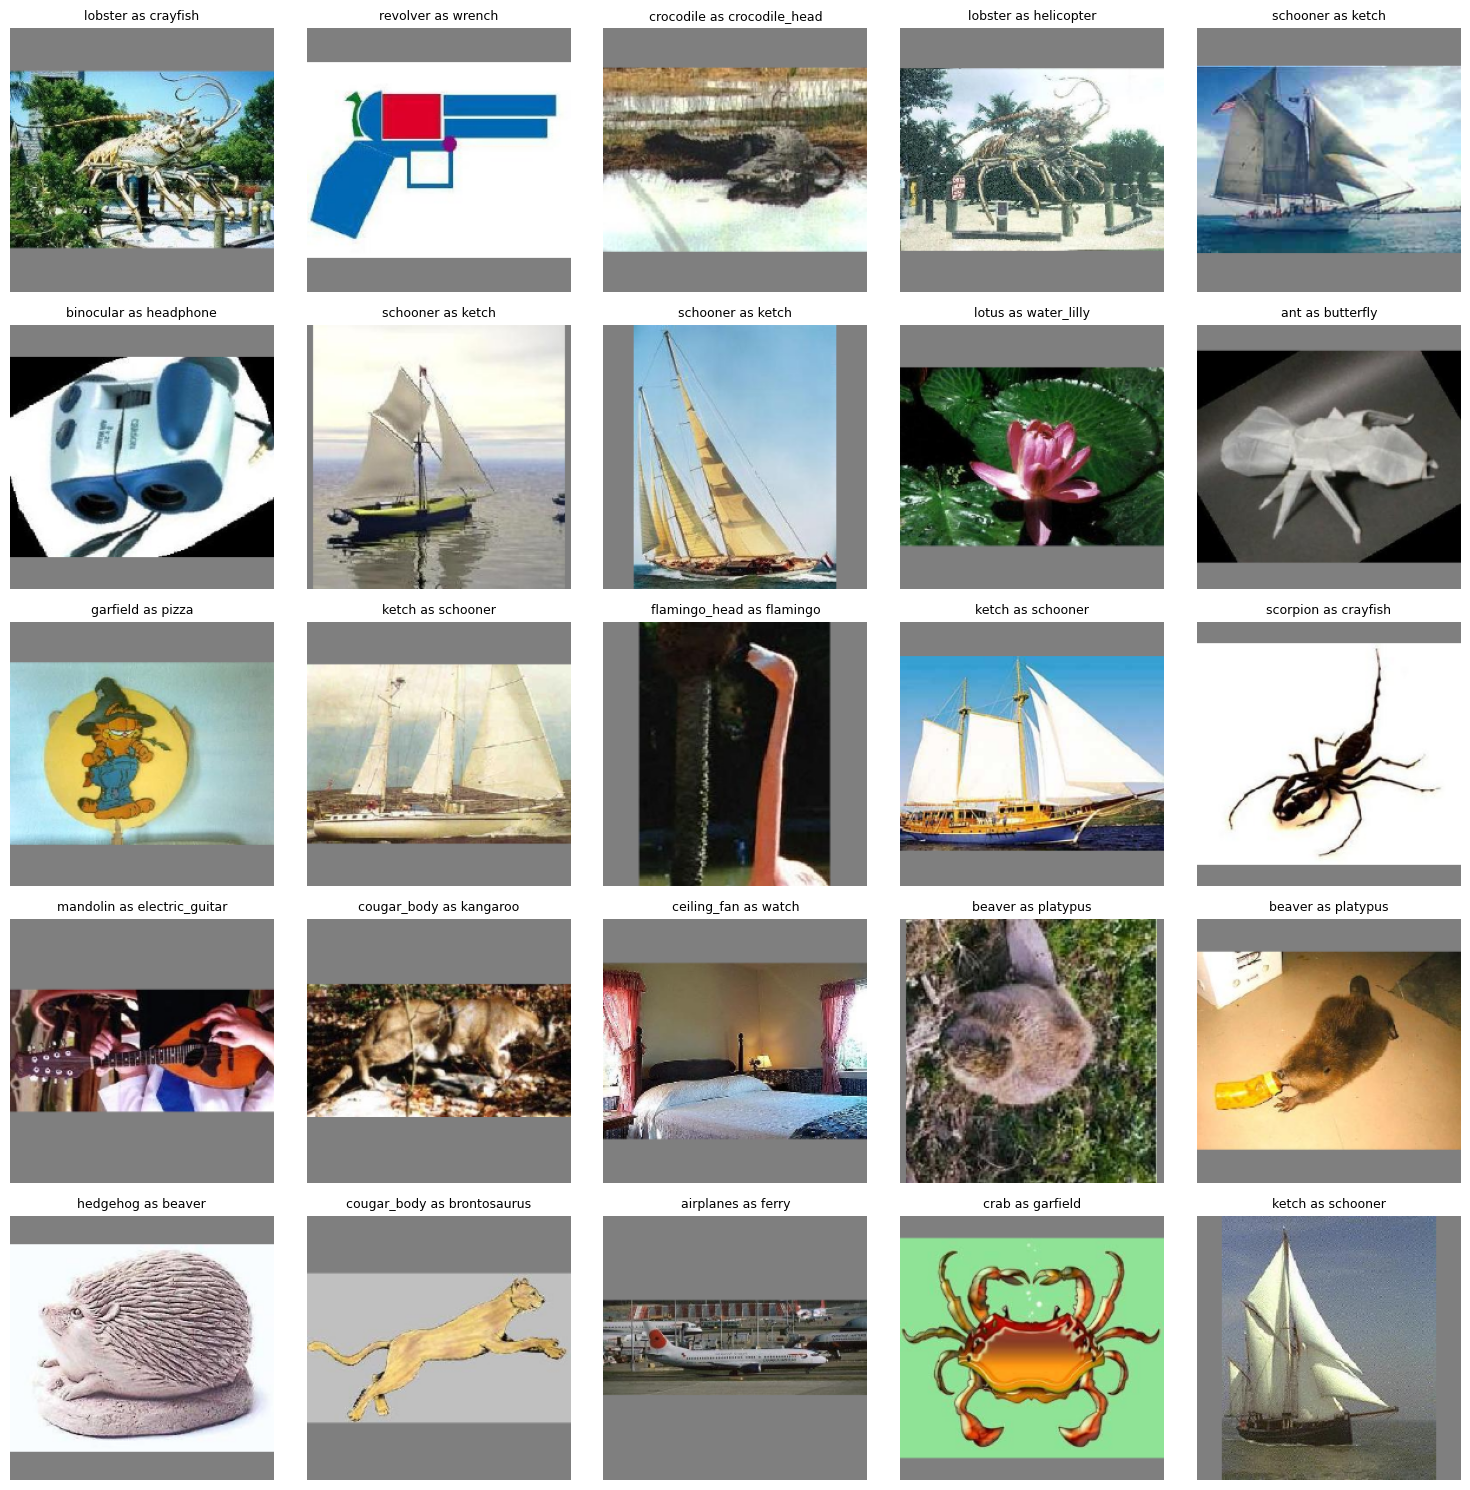

In [36]:
########################################################################################################################
# 9. EVALUACIJA MODELA
########################################################################################################################

print("\nEvaluacija modela...")
res_train = model.evaluate(x_train_pp, y_train, batch_size=batch_size, verbose=0)
res_test = model.evaluate(x_test_pp, y_test, batch_size=batch_size, verbose=0)
print(f"Trening rezultati (Loss, Accuracy): {res_train}")
print(f"Test rezultati (Loss, Accuracy): {res_test}")

y_out = model.predict(x_test_pp, batch_size=batch_size)
y_out = np.argmax(y_out, axis=1)

# Kreiranje podfoldera na Drive-u za pogrešne predikcije
misclassified_folder = os.path.join(drive_results_folder, 'misclassified')
if not os.path.exists(misclassified_folder):
    os.makedirs(misclassified_folder)

i = 0
misclassified_for_grid = [] # Lista u koju smeštamo prvih 25 grešaka za grid

y_test_flat = y_test.flatten()
for img, out, exp in zip(x_test, y_out, y_test_flat):
    if out != exp:
        i += 1
        title = '{} as {}'.format(categories[int(exp)], categories[int(out)])

        # Čuvanje svake pogrešne slike na Drive
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(title)
        plt.savefig(os.path.join(misclassified_folder, '{} ({}).jpg'.format(i, title)))
        plt.close() # Oslobađanje memorije zatvaranjem figure nakon čuvanja

        # Zadržavanje prvih 25 slika za prikaz u Colab-u
        if len(misclassified_for_grid) < 25:
            misclassified_for_grid.append((img, title))

print(f"\nPogrešne predikcije ({i} komada) su sačuvane na Drive-u u folderu: {misclassified_folder}")

# Prikaz prvih 25 pogrešnih predikcija u gridu
if misclassified_for_grid:
    print("\nPrikaz prvih (do 25) loše klasifikovanih slika:")
    cols = 5
    # Računanje broja redova u slučaju da model ima manje od 25 grešaka ukupno
    rows = min(5, (len(misclassified_for_grid) + cols - 1) // cols)

    plt.figure(figsize=(15, 3 * rows))
    for idx, (img, title) in enumerate(misclassified_for_grid):
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.title(title, fontsize=9) # Nešto manji font da bi stao u grid
        plt.axis('off')

    plt.tight_layout()
    plt.show()